In [2]:
import torch
from transformers import MllamaForConditionalGeneration

model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"

model_hf = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
)

sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

/home/andrewhinh/Desktop/Projects/formless/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 5/5 [00:00<00:00, 10.22it/s]


vision_model.class_embedding torch.Size([1280])
vision_model.patch_embedding.weight torch.Size([1280, 3, 14, 14])
vision_model.gated_positional_embedding.gate torch.Size([1])
vision_model.gated_positional_embedding.embedding torch.Size([1601, 1280])
vision_model.gated_positional_embedding.tile_embedding.weight torch.Size([9, 8197120])
vision_model.pre_tile_positional_embedding.gate torch.Size([1])
vision_model.pre_tile_positional_embedding.embedding.weight torch.Size([9, 5120])
vision_model.post_tile_positional_embedding.gate torch.Size([1])
vision_model.post_tile_positional_embedding.embedding.weight torch.Size([9, 5120])
vision_model.layernorm_pre.weight torch.Size([1280])
vision_model.layernorm_pre.bias torch.Size([1280])
vision_model.layernorm_post.weight torch.Size([1280])
vision_model.layernorm_post.bias torch.Size([1280])
vision_model.transformer.layers.0.self_attn.q_proj.weight torch.Size([1280, 1280])
vision_model.transformer.layers.0.self_attn.k_proj.weight torch.Size([1280, 

In [3]:
sd_hf["language_model.model.embed_tokens.weight"].view(-1)[:20]

tensor([ 0.0010,  0.0056, -0.0034, -0.0012, -0.0036,  0.0006, -0.0015, -0.0022,
        -0.0036, -0.0043, -0.0018, -0.0110,  0.0035,  0.0023, -0.0101,  0.0093,
        -0.0078, -0.0064, -0.0075,  0.0008], dtype=torch.bfloat16)

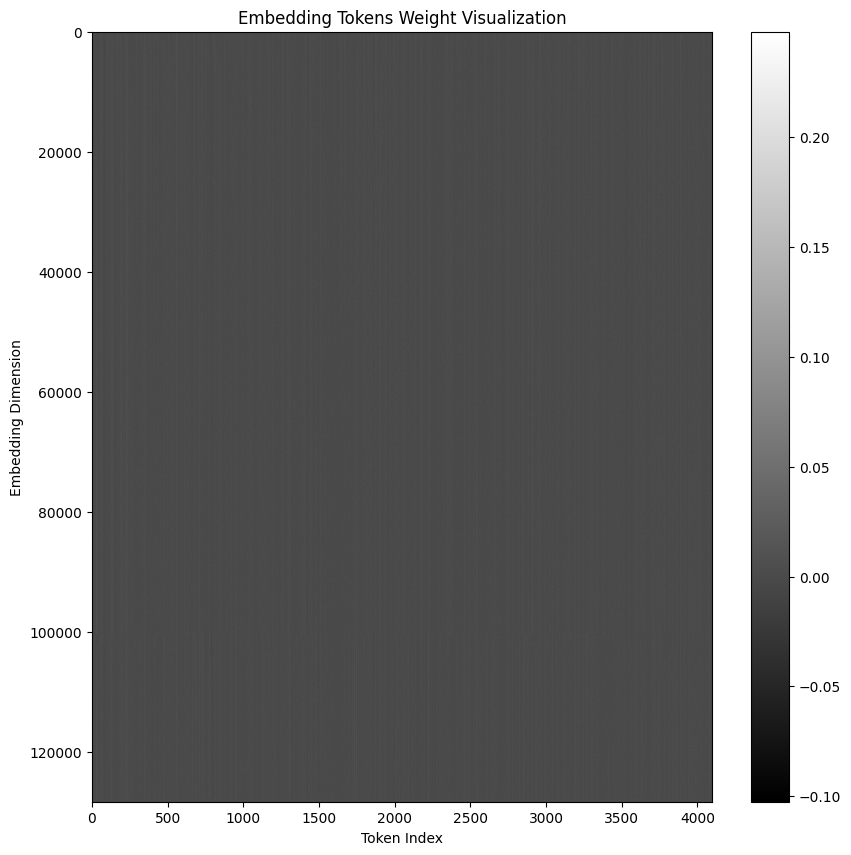

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(sd_hf["language_model.model.embed_tokens.weight"].float(), cmap="gray", aspect="auto")
plt.colorbar()
plt.title(label="Embedding Tokens Weight Visualization")
plt.xlabel("Token Index")
plt.ylabel("Embedding Dimension")
plt.show()

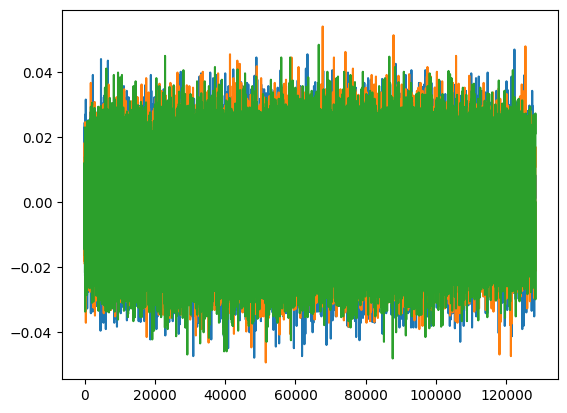

In [11]:
plt.plot(sd_hf["language_model.model.embed_tokens.weight"][:, 150].float())
plt.plot(sd_hf["language_model.model.embed_tokens.weight"][:, 200].float())
plt.plot(sd_hf["language_model.model.embed_tokens.weight"][:, 250].float())

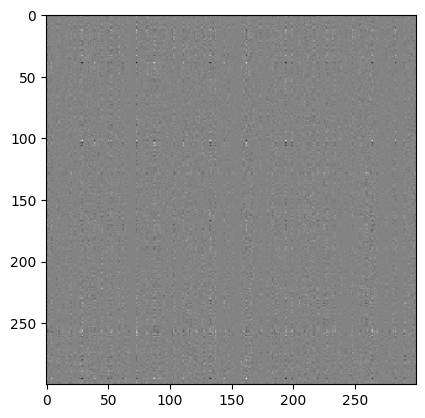

In [13]:
plt.imshow(sd_hf["language_model.model.layers.0.self_attn.q_proj.weight"][:300, :300].float(), cmap="gray")

In [ ]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = model_hf
model.eval()
model.to("cuda")
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11]  # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long)  # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1)  # (5, 8)
x = tokens.to("cuda")

# generate!
while x.size(1) < 30:  # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0]  # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :]  # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1)  # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix)  # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken

enc = tiktoken.get_encoding("gpt2")
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

In [ ]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open("input.txt", "r") as f:
    text = f.read()
data = text[:1000]  # first 1,000 characters
print(data[:100])

In [ ]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)
print(tokens[:24])

In [ ]:
import torch

buf = torch.tensor(tokens[: 24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

In [ ]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

In [ ]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

In [ ]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

In [ ]:
# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100  # e.g. 100 layers
for _ in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())

In [ ]:
import torch

# super simple little MLP
net = torch.nn.Sequential(torch.nn.Linear(16, 32), torch.nn.GELU(), torch.nn.Linear(32, 1))
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!

In [ ]:
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4  # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])

In [ ]:
# parse and visualize the logfile
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = {  # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = {  # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("log124M_40B/log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(v.items())
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy, strict=False))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
xs, ys = streams_xy["train"]  # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz}) train loss")
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"]  # validation loss
plt.plot(xs, ys, label=f"nanogpt ({sz}) val loss")
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color="r", linestyle="--", label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale("log")
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"]  # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color="r", linestyle="--", label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color="g", linestyle="--", label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))